# [LAB-09] 7. [PBT] 선형회귀 파이프라인 - 연습문제

## 준비작업

### 라이브러리 참조

In [1]:
from jussam import load_data
from helpers import *

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


## 📚 부동산 애널리스트의 리모델링 자문

### 당신은 지역 부동산 리서치 회사의 애널리스트입니다.

지난주 EDA에서 주택 545건을 살펴본 결과, 면적·방 개수·편의 설비 등 12개 조건이 **모두** 가격과 유의한 관련이 있고 서로 중복되는 변수도 없다는 결론을 냈습니다.

그런데 팀장은 "관련이 있다는 것까지는 알겠고, 그래서 가격이 얼마나 달라지느냐"고 되묻습니다. 

마침 리모델링을 앞둔 고객이 "예산으로 집을 넓히는 게 나은지, 설비를 하나 더 들이는 게 나은지"를 물어 왔습니다.

전처리를 한 단계씩 쌓아 올리며 가격 예측 모델을 만들고, 고객에게 무엇을 권할지 근거를 찾아내세요.

### 💻 코드 작성

#### 데이터 가져오기와 타입 확정

In [2]:
origin = load_data("housing_qtcheck")
cat_desc = load_data("housing_categorical_summary")

# 명목형 기술통계량 표의 컬럼명이 곧 명목형 변수 목록이다
df = my_qtcheck.set_type(origin, as_category=cat_desc.columns)

📚 주택 가격 데이터셋의 품질 검사 완료 버전 (출처: 자체 정제)
📚 주택 가격 데이터셋의 범주형 변수에 대한 기술 통계량 (출처: 자체 작업)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   price             545 non-null    int64   
 1   area              545 non-null    int64   
 2   bedrooms          545 non-null    int64   
 3   bathrooms         545 non-null    int64   
 4   stories           545 non-null    int64   
 5   mainroad          545 non-null    category
 6   guestroom         545 non-null    category
 7   basement          545 non-null    category
 8   hotwaterheating   545 non-null    category
 9   airconditioning   545 non-null    category
 10  parking           545 non-null    int64   
 11  prefarea          545 non-null    category
 12  furnishingstatus  545 non-null    category
dtypes: category(7), int64(6)
memory usage: 30.3 KB


#### 변수 유형 분류

In [3]:
target = "price"

nominal_cols = my_qtcheck.get_categorical_column_names(df)
continuous_cols = my_qtcheck.get_number_column_names(df)
continuous_cols.remove(target)

print("종속변수 :", target)
print("명목형   :", nominal_cols)
print("연속형   :", continuous_cols)

종속변수 : price
명목형   : ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']
연속형   : ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']


#### 전처리 체크포인트별 모델 적합

In [4]:
# 전처리를 하나씩 누적한 체크포인트 (아래로 갈수록 전처리가 하나 더 붙는다)
checkpoints = {
    "0_기준선":    dict(),
    "1_로그변환":   dict(log=True),
    "2_이상치대체": dict(log=True, outlier=True),
    "3_공선성제거": dict(log=True, outlier=True, vif=True),
    "4_스케일링":   dict(log=True, outlier=True, vif=True, scale=True),
}

fits = {}

for name in checkpoints:
    print(f"\n▶︎ --- {name} ---")
    fits[name] = my_ols.fit_pipeline(df, target, nominal_cols=nominal_cols,
                                     name=name, verbose=False, **checkpoints[name])


▶︎ --- 0_기준선 ---

유의하지 않은 독립변수 제거 → furnishingstatus_1 (p = 0.7145)
유의하지 않은 독립변수 제거 → bedrooms (p = 0.1161)
유의하지 않은 독립변수 제거 → guestroom (p = 0.0532)

▶︎ --- 1_로그변환 ---

유의하지 않은 독립변수 제거 → furnishingstatus_1 (p = 0.6381)
유의하지 않은 독립변수 제거 → bedrooms (p = 0.1031)

▶︎ --- 2_이상치대체 ---

유의하지 않은 독립변수 제거 → furnishingstatus_1 (p = 0.6548)
유의하지 않은 독립변수 제거 → bedrooms (p = 0.1272)

▶︎ --- 3_공선성제거 ---

완료! 남은 변수: ['area', 'bathrooms', 'bedrooms', 'parking', 'stories']
최대 VIF = 1.44

유의하지 않은 독립변수 제거 → furnishingstatus_1 (p = 0.6548)
유의하지 않은 독립변수 제거 → bedrooms (p = 0.1272)

▶︎ --- 4_스케일링 ---

완료! 남은 변수: ['area', 'bathrooms', 'bedrooms', 'parking', 'stories']
최대 VIF = 1.44

유의하지 않은 독립변수 제거 → furnishingstatus_1 (p = 0.6548)
유의하지 않은 독립변수 제거 → bedrooms (p = 0.1272)


#### 성능 비교와 모델 선택

In [5]:
final_fit = my_ols.compare_models(fits)

print("최종 모델 :", final_fit.name_)
print("독립변수  :", int(final_fit.df_model), "개")

,변수수,R2(모델척도),Adj.R2,AIC,BIC,R2(원본척도),RMSE,MAE,Gap(%)
모델,,,,,,,,,
0_기준선,10,0.677,0.671,16692.908,16740.216,0.677,1061796.015,778354.185,2.720
2_이상치대체,11,0.703,0.697,-169.826,-118.216,0.694,1033709.305,743145.179,0.000
3_공선성제거,11,0.703,0.697,-169.826,-118.216,0.694,1033709.305,743145.179,0.000
4_스케일링,11,0.703,0.697,-169.826,-118.216,0.694,1033709.305,743145.179,0.000
1_로그변환,11,0.703,0.697,-168.711,-117.102,0.694,1034311.391,744527.090,0.060


최종 모델 : 0_기준선
독립변수  : 10 개


#### 도메인 지식 반영 — 편의 요소를 하나의 점수로

In [ ]:
# 모두 "이 주택이 어떤 편의 요소를 갖췄는가"를 묻는 같은 성격의 yes/no 항목이다
amenity_cols = ["mainroad", "guestroom", "basement",
                "hotwaterheating", "airconditioning", "prefarea"]

df2 = df.copy()
df2["amenity"] = sum((df2[c] == "yes").astype(int) for c in amenity_cols)
df2 = df2.drop(columns=amenity_cols)

# 명목형 목록도 df2 기준으로 다시 잡는다
nominal_cols2 = [c for c in nominal_cols if c in df2.columns]

print("명목형 :", nominal_cols2)
print(df2["amenity"].value_counts().sort_index().to_string())
df2.head()

명목형 : ['furnishingstatus']
amenity
0     42
1    172
2    164
3    102
4     50
5     15


,price,area,bedrooms,bathrooms,stories,parking,furnishingstatus,amenity
0,13300000,7420,4,2,3,2,furnished,3
1,12250000,8960,4,4,4,3,furnished,2
2,12250000,9960,3,2,2,2,semi-furnished,3
3,12215000,7500,4,2,2,3,furnished,4
4,11410000,7420,4,1,2,2,furnished,4


#### 도메인 버전 모델 적합 (fits 에 누적)

In [7]:
domain_checkpoints = {
    "5_도메인_기준선":    dict(),
    "6_도메인_로그변환":   dict(log=True),
    "7_도메인_이상치대체": dict(log=True, outlier=True),
    "8_도메인_공선성제거": dict(log=True, outlier=True, vif=True),
}

for name in domain_checkpoints:
    print(f"\n▶︎ --- {name} ---")
    fits[name] = my_ols.fit_pipeline(df2, target, nominal_cols=nominal_cols2,
                                     name=name, verbose=False, **domain_checkpoints[name])

print("\n누적된 모델 :", len(fits), "개")


▶︎ --- 5_도메인_기준선 ---

유의하지 않은 독립변수 제거 → furnishingstatus_1 (p = 0.6083)
유의하지 않은 독립변수 제거 → bedrooms (p = 0.1361)

▶︎ --- 6_도메인_로그변환 ---

유의하지 않은 독립변수 제거 → furnishingstatus_1 (p = 0.7806)
유의하지 않은 독립변수 제거 → bedrooms (p = 0.1215)

▶︎ --- 7_도메인_이상치대체 ---

유의하지 않은 독립변수 제거 → furnishingstatus_1 (p = 0.7954)
유의하지 않은 독립변수 제거 → bedrooms (p = 0.1457)

▶︎ --- 8_도메인_공선성제거 ---

완료! 남은 변수: ['amenity', 'area', 'bathrooms', 'bedrooms', 'parking', 'stories']
최대 VIF = 1.45

유의하지 않은 독립변수 제거 → furnishingstatus_1 (p = 0.7954)
유의하지 않은 독립변수 제거 → bedrooms (p = 0.1457)

누적된 모델 : 9 개


#### 전체 모델 성능 비교

In [8]:
final_fit = my_ols.compare_models(fits)

print("최종 모델 :", final_fit.name_)
print("독립변수  :", int(final_fit.df_model), "개")

,변수수,R2(모델척도),Adj.R2,AIC,BIC,R2(원본척도),RMSE,MAE,Gap(%)
모델,,,,,,,,,
7_도메인_이상치대체,6,0.695,0.691,-164.350,-134.245,0.680,1057249.730,758574.822,2.280
8_도메인_공선성제거,6,0.695,0.691,-164.350,-134.245,0.680,1057249.730,758574.822,2.280
6_도메인_로그변환,6,0.694,0.691,-163.113,-133.008,0.679,1058061.392,759904.466,2.360
5_도메인_기준선,6,0.669,0.665,16698.145,16728.250,0.669,1074769.154,781098.845,3.970
0_기준선,10,0.677,0.671,16692.908,16740.216,0.677,1061796.015,778354.185,2.720
2_이상치대체,11,0.703,0.697,-169.826,-118.216,0.694,1033709.305,743145.179,0.000
3_공선성제거,11,0.703,0.697,-169.826,-118.216,0.694,1033709.305,743145.179,0.000
4_스케일링,11,0.703,0.697,-169.826,-118.216,0.694,1033709.305,743145.179,0.000
1_로그변환,11,0.703,0.697,-168.711,-117.102,0.694,1034311.391,744527.090,0.060


최종 모델 : 7_도메인_이상치대체
독립변수  : 6 개


#### 최종 채택 모델 결과 보고

## 최종 모델: 7_도메인_이상치대체

### ▶︎ 성능 보고

#### 1) 모형 적합도

**Note. n = 545. F(6, 538) = 204.03, p < 0.001, R² = 0.695, Adj.R² = 0.691, Durbin-Watson = 1.31**

log(price)를 종속변수로, log(area), log(bathrooms), log(stories), parking, amenity, furnishingstatus_2(을)를 독립변수로한 다중선형회귀분석 결과, 모형은 통계적으로 유의하였다.

> F(6, 538) = 204.03, p < 0.001, R² = 0.695.

즉, log(area), log(bathrooms), log(stories), parking, amenity, furnishingstatus_2는 log(price)의 약 69.47%를 설명하는 것으로 나타났다.

#### 2) 회귀계수 보고표

,종속변수,독립변수,B,표준오차,표준오차(HC3),β,t,t(HC3),유의확률,유의확률(HC3),공차,VIF
0,price,amenity,0.106,0.008,0.007,0.341,13.091,14.412,0.000,0.000,0.835,1.197
1,price,area,0.316,0.025,0.026,0.337,12.511,11.957,0.000,0.000,0.781,1.281
2,price,stories,0.195,0.021,0.020,0.237,9.405,9.890,0.000,0.000,0.892,1.121
3,price,bathrooms,0.267,0.030,0.032,0.234,8.980,8.310,0.000,0.000,0.837,1.195
4,price,furnishingstatus_2,-0.117,0.020,0.020,-0.147,-5.968,-5.760,0.000,0.000,0.934,1.070
5,price,parking,0.052,0.012,0.012,0.116,4.491,4.343,0.000,0.000,0.844,1.184


#### 3) 영향력 순위 시각화 (표준화 계수 β)

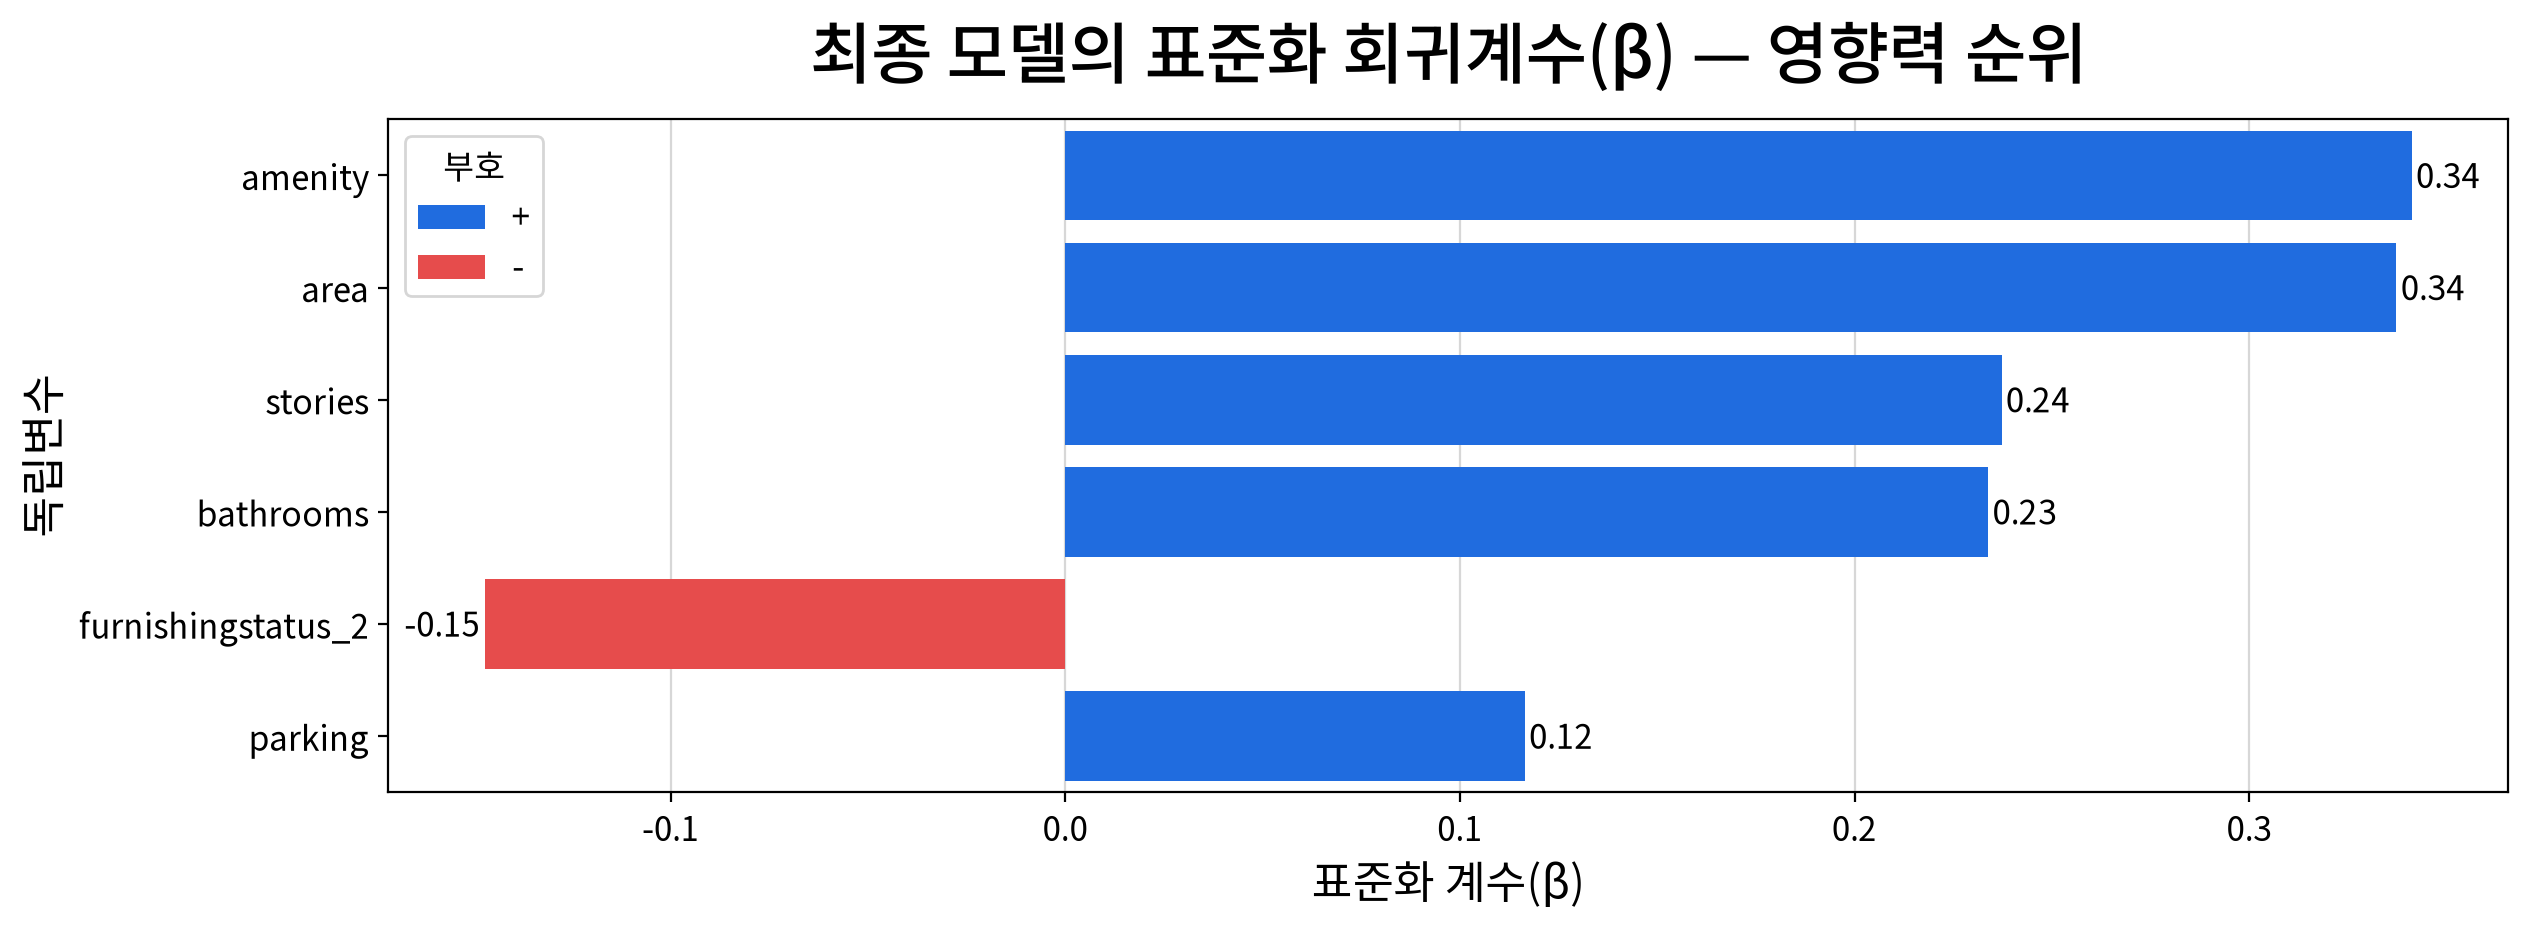

#### 4) 회귀계수 해석 문장

- **area**의 회귀계수는 **B = 0.32**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(538) = 11.96**, **p < .001**)      
즉, area가 **1% 증가**할 때 price는 평균적으로 약 **0.32% 증가**하는 것으로 해석된다.
- **bathrooms**의 회귀계수는 **B = 0.27**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(538) = 8.31**, **p < .001**)      
즉, bathrooms가 **1% 증가**할 때 price는 평균적으로 약 **0.27% 증가**하는 것으로 해석된다.
- **stories**의 회귀계수는 **B = 0.19**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(538) = 9.89**, **p < .001**)      
즉, stories가 **1% 증가**할 때 price는 평균적으로 약 **0.19% 증가**하는 것으로 해석된다.
- **parking**의 회귀계수는 **B = 0.05**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(538) = 4.34**, **p < .001**)      
즉, parking가 **1 증가**할 때 price는 평균적으로 약 **5.33% 증가**하는 것으로 해석된다.
- **amenity**의 회귀계수는 **B = 0.11**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(538) = 14.41**, **p < .001**)      
즉, amenity가 **1 증가**할 때 price는 평균적으로 약 **11.21% 증가**하는 것으로 해석된다.
- **furnishingstatus_2**의 회귀계수는 **B = -0.12**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(538) = -5.76**, **p < .001**)      
즉, furnishingstatus_2가 **1 증가**할 때 price는 평균적으로 약 **11.01% 감소**하는 것으로 해석된다.

> ※ 위 **t**와 **유의확률**은 등분산 가정이 충족되지 않은 경우를 대비해 **HC3 로버스트 표준오차**로 계산한 값이다.     
회귀계수(B)와 효과 크기 해석은 일반 OLS와 동일하며,     
표준오차만 이분산에 강건하게 보정되어 유의성 판정이 달라질 수 있다.

---

### ▶︎ 회귀모형 가정 검정

#### 1) 선형성 검정

,statistic,p-value,linearity,result
Ramsey RESET,0.176,0.675,True,귀무가설 채택 → 선형성 위배 근거 없음


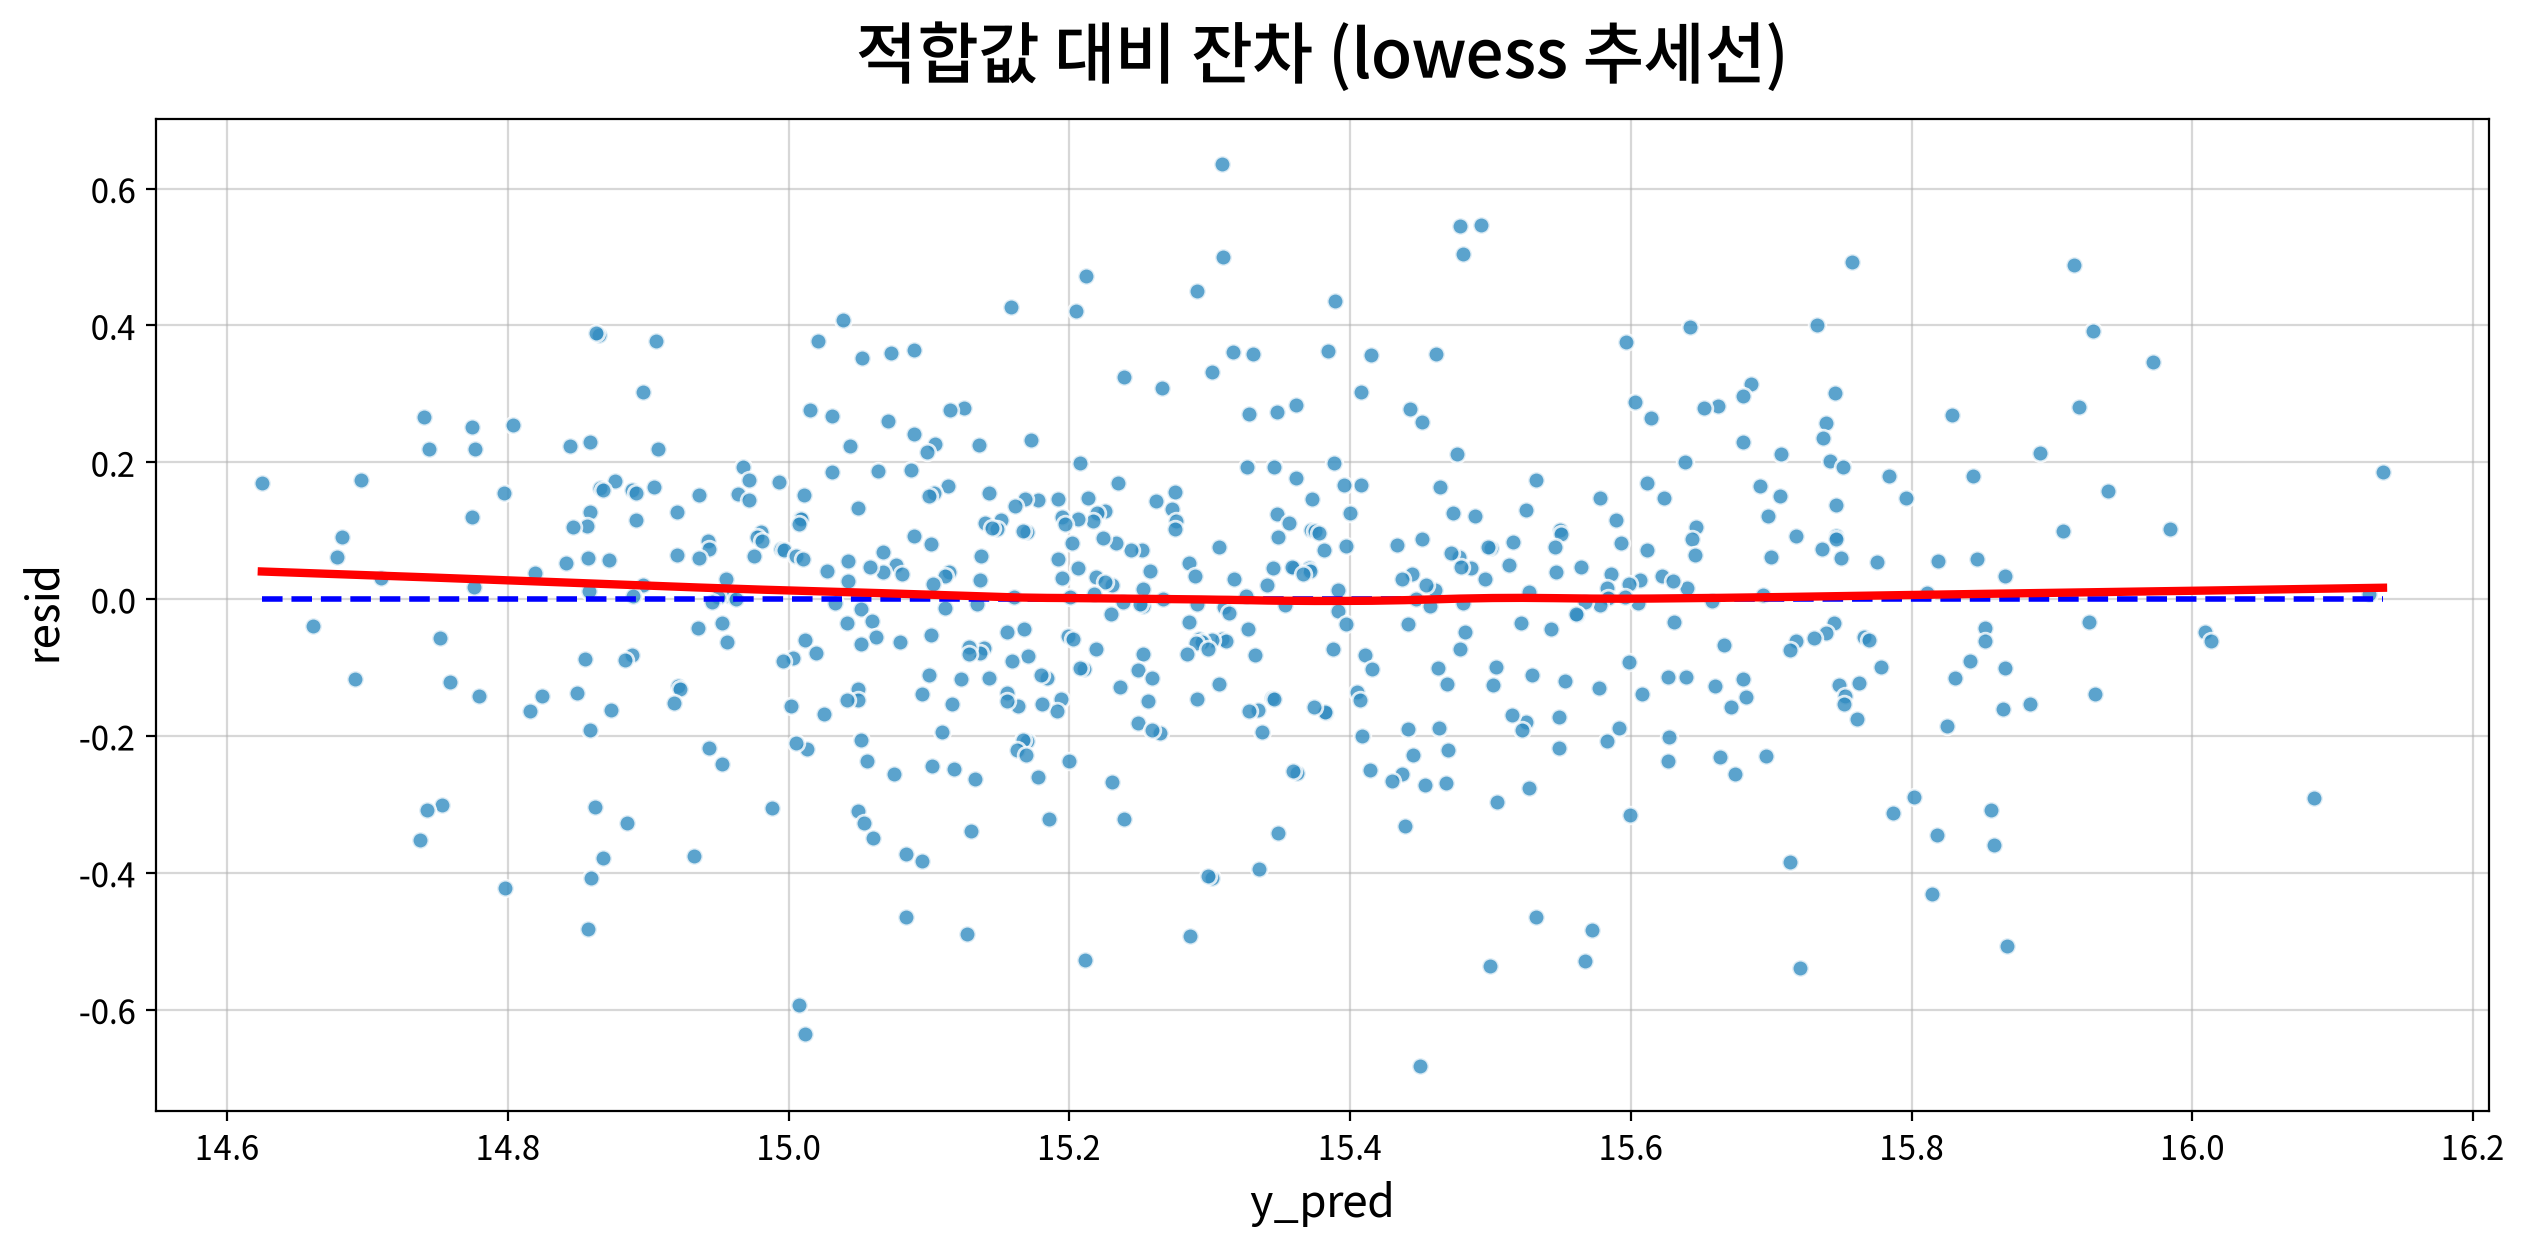

#### 2) 정규성 검정

,statistic,p-value,normality,result
Kolmogorov-Smirnov,0.040,0.331,True,귀무가설 채택 → 정규성 만족


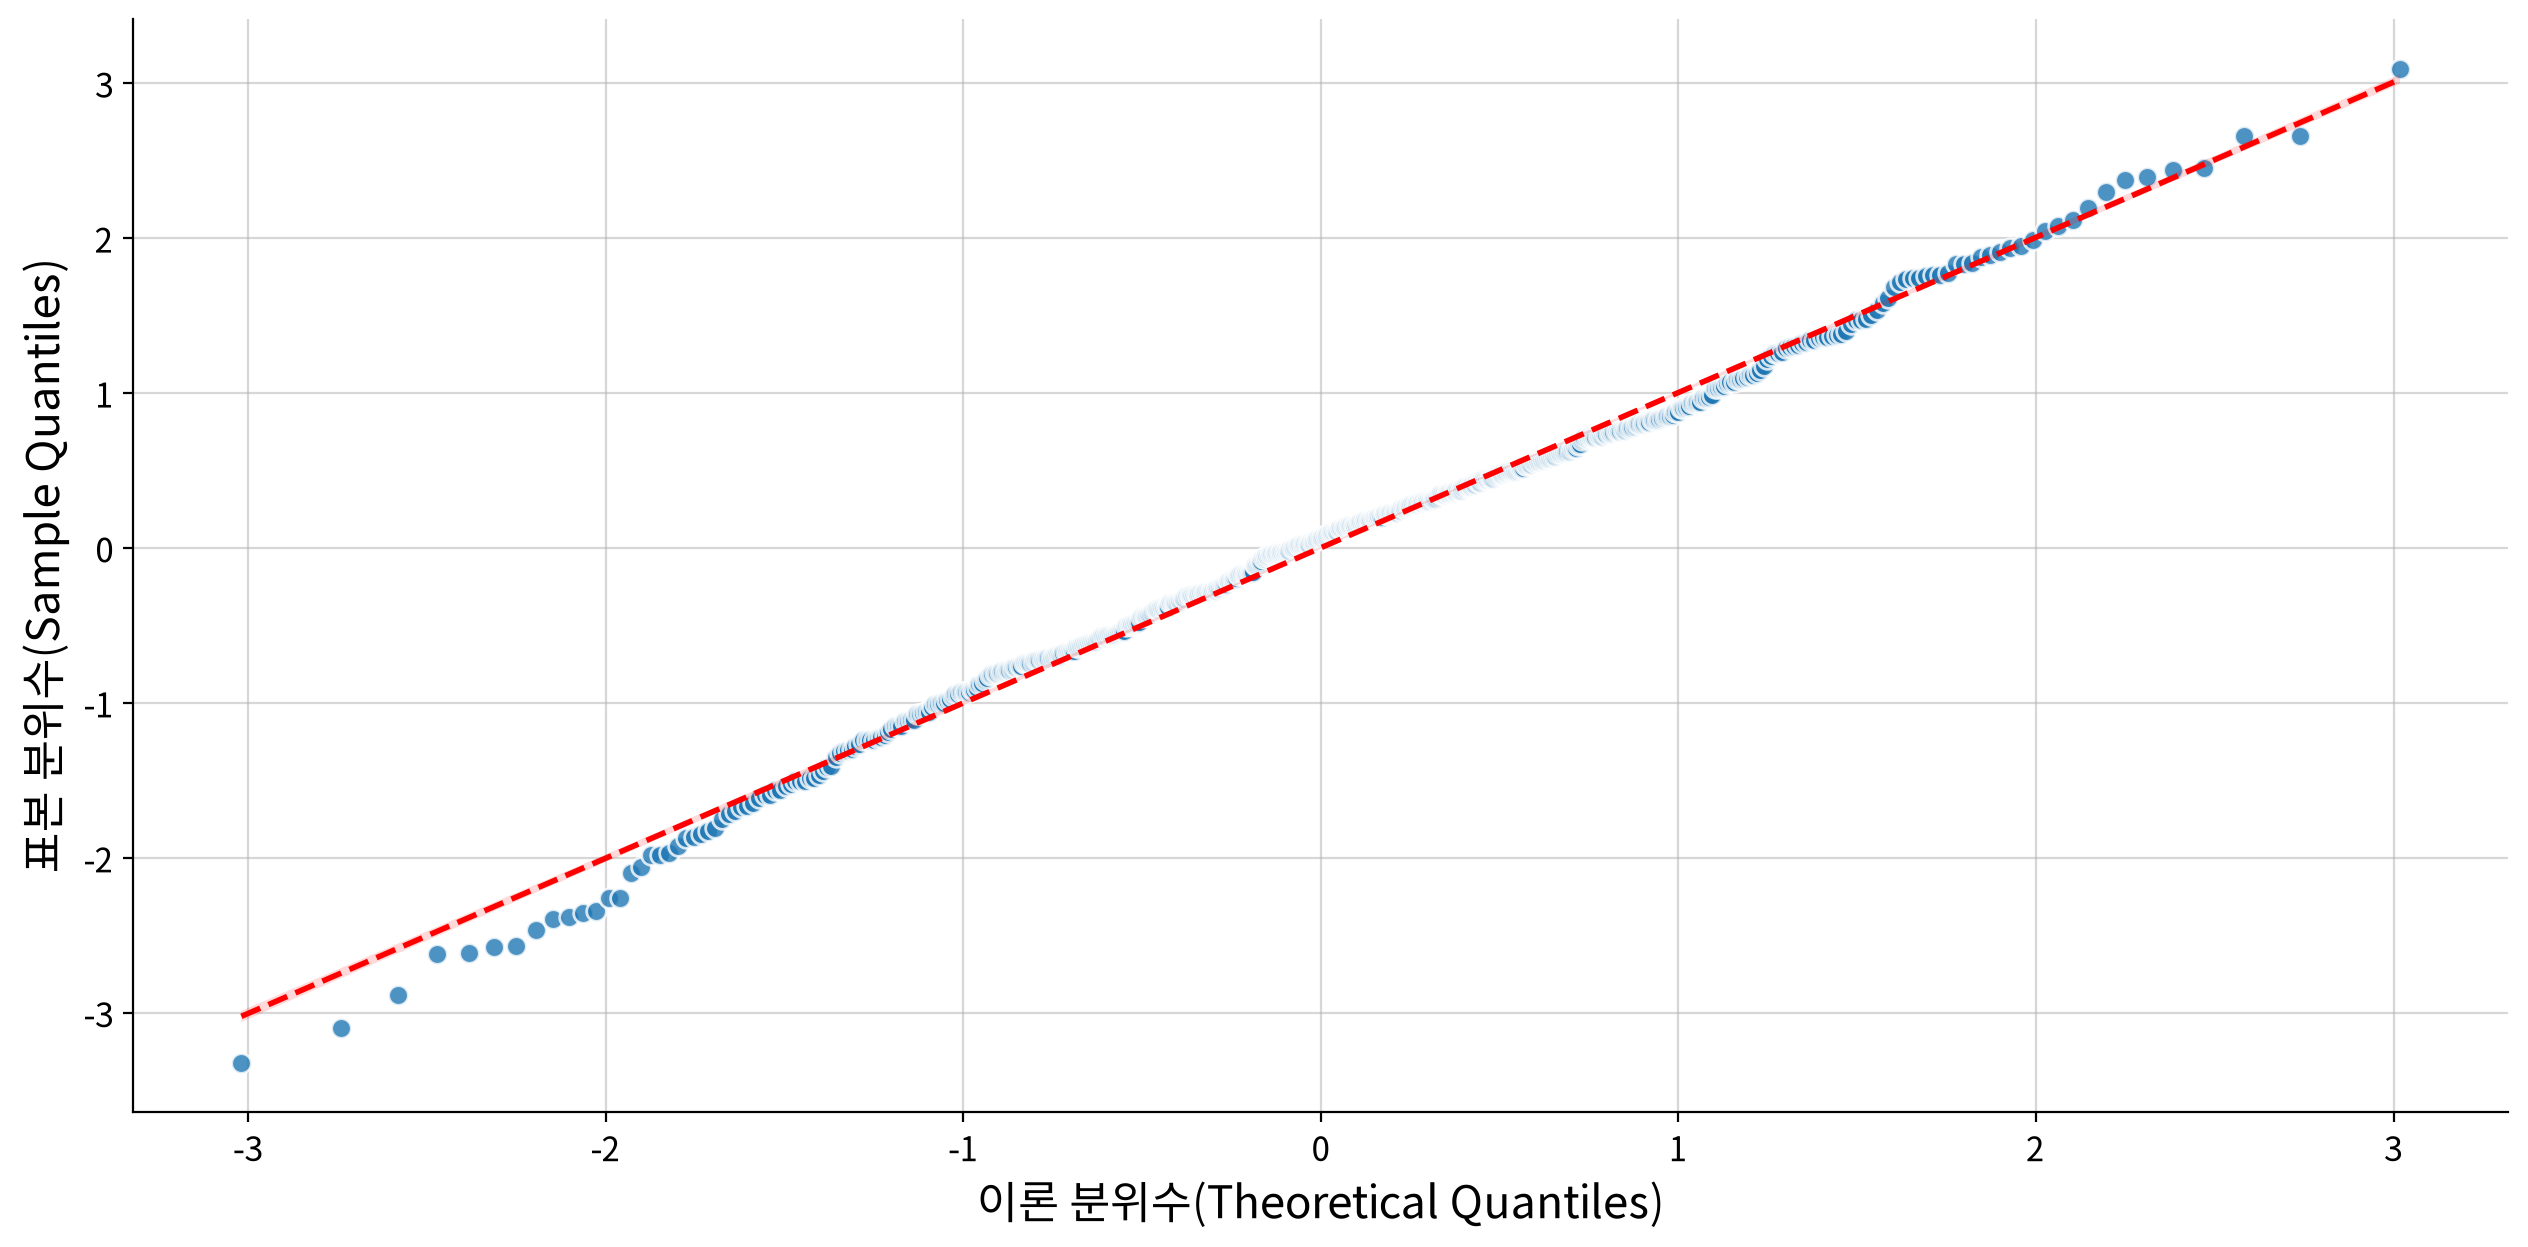

,기대(%),허용범위(%),실제(%),판정
구간,,,,
±1√MSE,68.000,64~72,72.110,위배
±2√MSE,95.000,93~97,94.860,충족
±3√MSE,99.700,99~100,99.450,충족


√MSE = 0.21 · 구간 규칙 판정: 정규성 위배


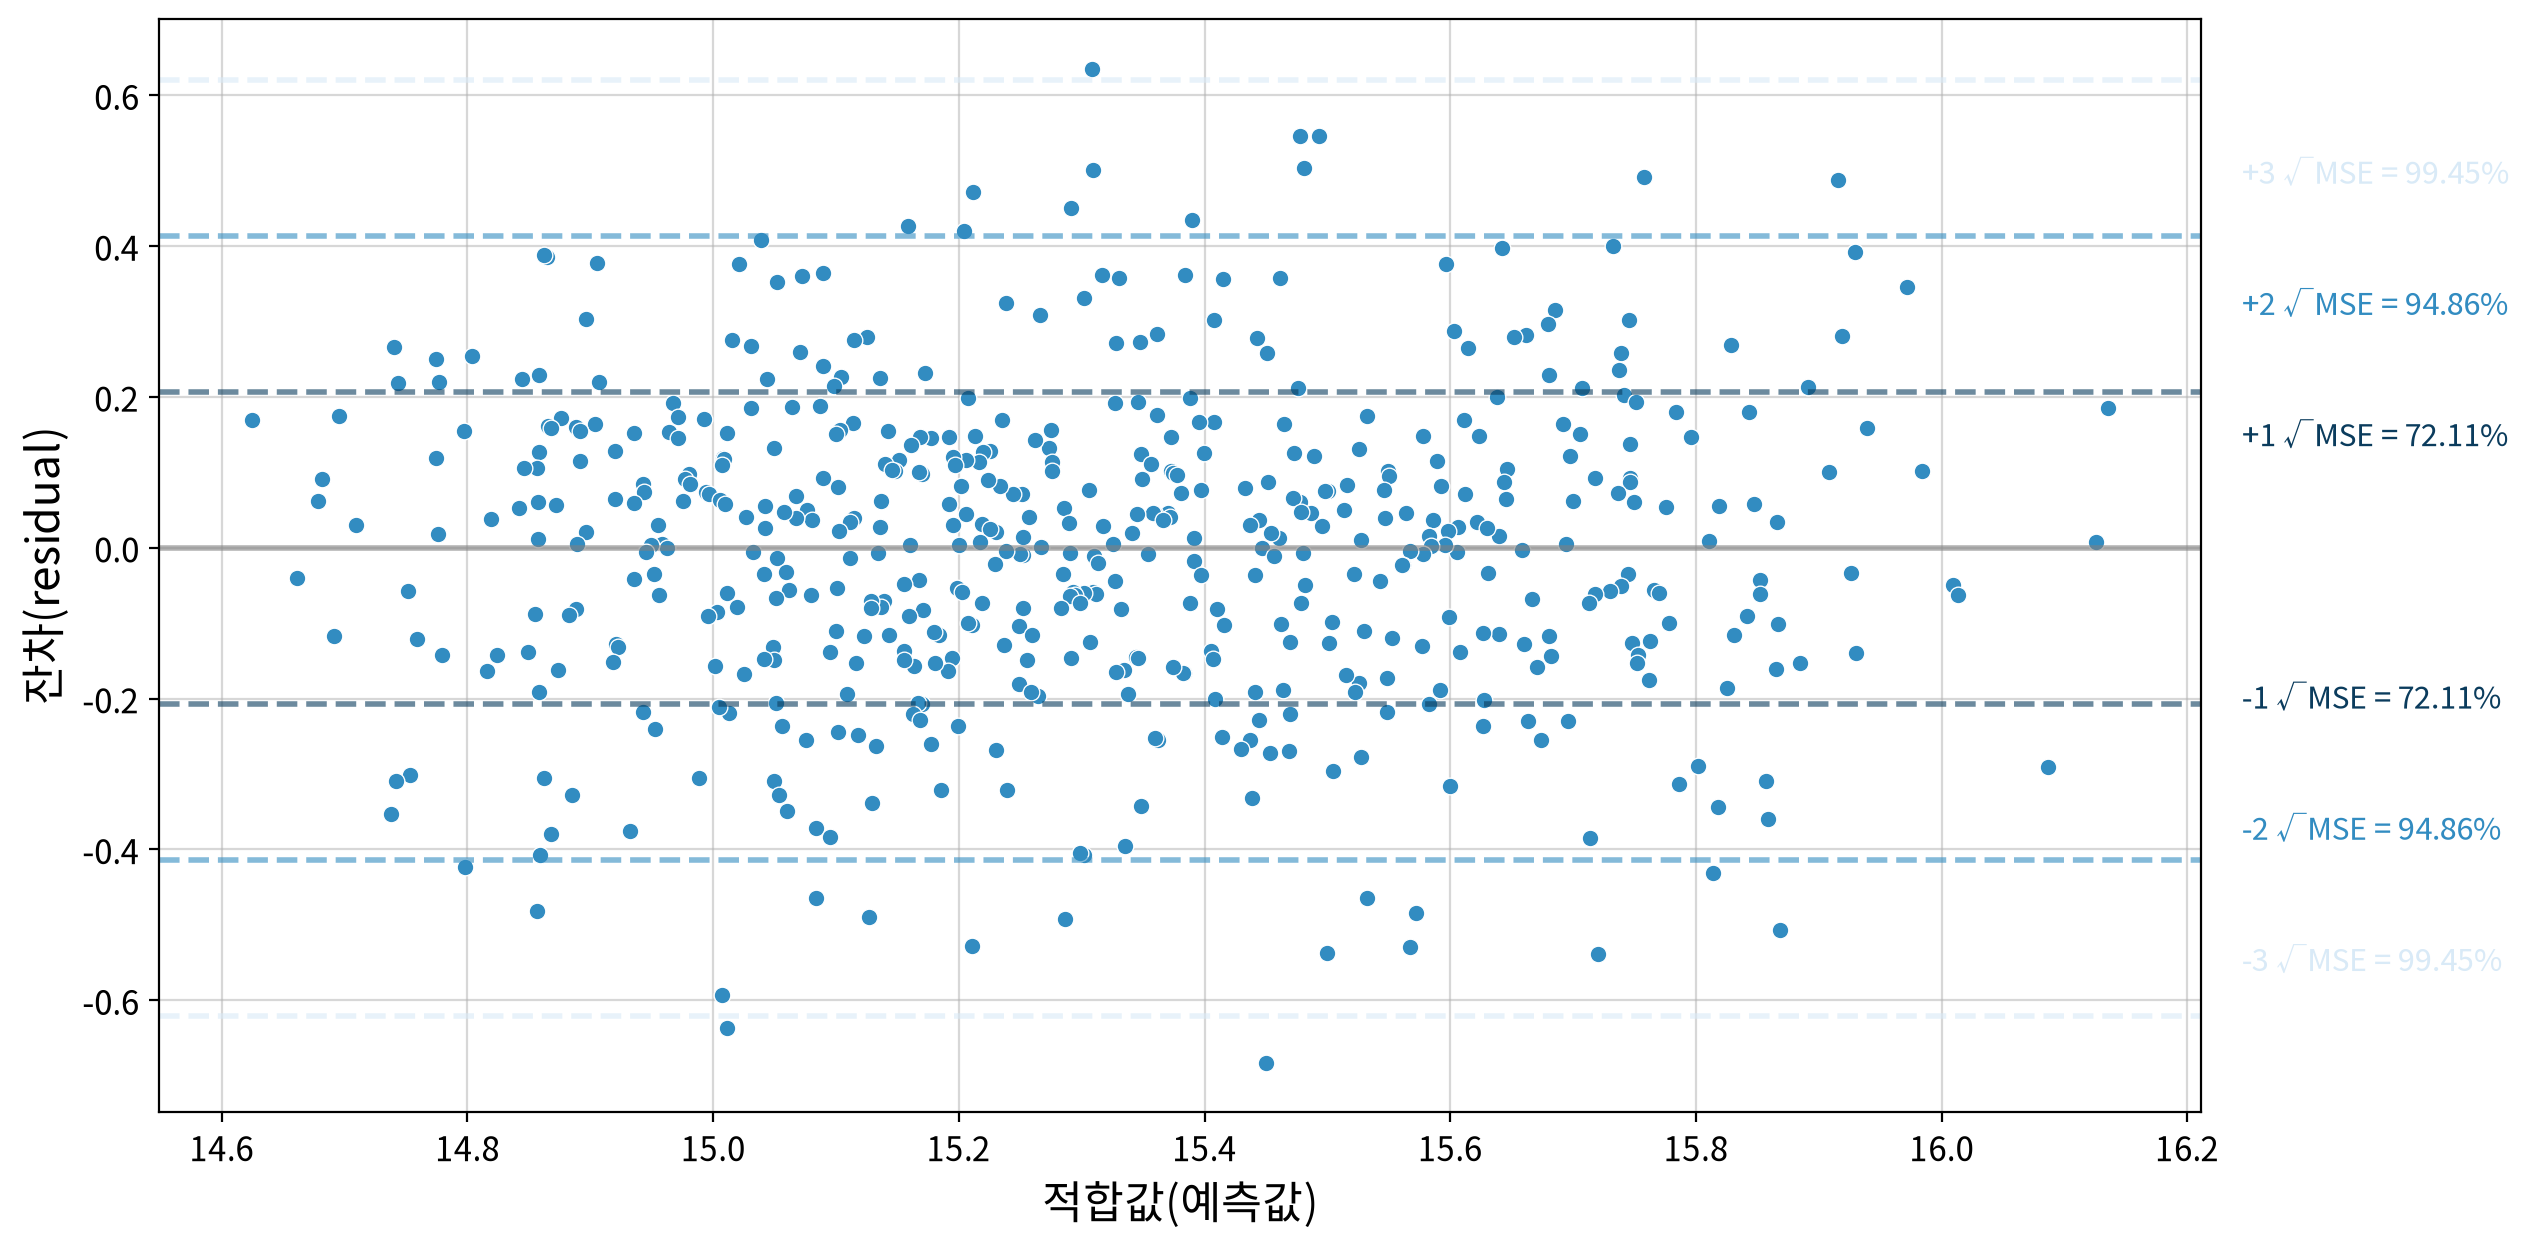

#### 3) 등분산성 검정

,LM statistic,LM p-value,F statistic,F p-value,homoscedasticity,result
Breusch-Pagan,15.090,0.020,2.554,0.019,False,대립가설 채택 → 등분산 아님


#### 4) 독립성 검정

,statistic,independence,result
Durbin-Watson,1.310,False,독립성 위반 (양(+)의 자기상관)


In [9]:
my_ols.report_model(final_fit)

### 문제 풀이

#### 1. 가격을 설명하는 데 도움이 되지 않는 변수는 모델에서 자동으로 걸러집니다. 로그 변환과 이상치 대체를 마친 모델에서 이렇게 탈락한 숫자형 변수는 무엇인가요?

- **정답**: `bedrooms`
- **복습 개념**: 후진소거법(backward elimination)입니다. 모든 독립변수를 넣고 시작해 유의하지 않은 변수를 하나씩 떨어뜨려, 남는 변수 전부가 유의한 상태로 만듭니다.
- **풀이 접근**: 전처리 조합(로그 변환 + 이상치 대체)을 적용해 회귀모델을 적합하면, 제거되는 변수의 이름과 그때의 유의확률이 순서대로 출력됩니다. 그중 숫자형(연속형) 변수를 찾습니다.
- **근거(계산 결과)**: `furnishingstatus_1`(p ≈ 0.64)과 `bedrooms`(p ≈ 0.11)가 차례로 빠졌고, 이 중 숫자형은 **bedrooms** 입니다. EDA에서 `bedrooms`는 가격과 ρ = +0.391로 분명히 유의했는데도 회귀에서는 탈락했습니다.
- **헷갈리기 쉬운 점**: "EDA에서 유의했는데 왜 빠지지?"라고 생각하기 쉽습니다. 상관분석은 `bedrooms` **혼자** 가격과 얼마나 같이 움직이는지를 보지만, 회귀는 `area`가 이미 들어간 **뒤에** `bedrooms`가 추가로 설명하는 몫을 봅니다. 넓은 집이 곧 방이 많은 집이니, 면적이 방 개수의 정보를 대부분 흡수해 버린 것입니다.

#### 2. 독립변수들끼리 정보가 겹치면 계수가 불안정해지므로 겹침 정도를 VIF 수치로 점검합니다. 점검 결과 걸러낼 변수가 하나도 없었는데, 이때 확인된 가장 큰 값은 얼마인가요? (소수 둘째 자리)

- **정답**: `1.41`
- **복습 개념**: 분산팽창계수(VIF)로 판정하는 다중공선성입니다. 보통 10을 넘으면 그 변수는 다른 변수들로 거의 설명된다고 보고 제거 대상으로 삼습니다.
- **풀이 접근**: 전처리 조합에 공선성 제거 단계를 켜서 모델을 적합하면, 남은 변수 목록과 그 최댓값이 함께 출력됩니다.
- **근거(계산 결과)**: 숫자형 5개(`area`·`bathrooms`·`bedrooms`·`parking`·`stories`)가 모두 살아남았고 최댓값은 **1.41** 로, 임계값 10에 한참 못 미칩니다. VIF가 1이면 겹침이 전혀 없다는 뜻이니 1.41은 사실상 독립에 가깝습니다.
- **함께 생각해 볼 점**: 제거 대상이 없다는 것은 곧 **공선성 제거 단계가 아무 일도 하지 않았다**는 뜻입니다. 성능표에서 `3_공선성제거`·`4_스케일링`의 지표가 `2_이상치대체`와 소수점까지 완전히 똑같은 이유가 여기에 있습니다. 전처리를 켰다고 해서 늘 데이터가 바뀌는 것은 아닙니다.

#### 3. 다섯 모델의 성능표를 놓고 보면, 예측 오차가 가장 작은 모델이 최종 선택되지 **않았습니다**. 최종 선택된 모델이 사용하는 독립변수는 몇 개인가요?

- **정답**: `10`
- **복습 개념**: 간명성(parsimony) 원칙에 따른 모델 선택입니다. 1위와의 성능 격차가 근소하다면(보통 5% 이내), 변수를 더 적게 쓰는 쪽이 더 좋은 모델입니다.
- **풀이 접근**: 성능표에서 RMSE 1위와 각 모델의 격차(%)를 확인하고, 근소 격차 그룹 안에서 변수 수가 가장 적은 모델을 찾습니다. 채택된 모델의 독립변수 개수는 모델 객체에서 직접 확인할 수 있습니다.
- **근거(계산 결과)**: RMSE 1위는 1,031,743이지만 최종 채택된 모델은 오차 1,061,796으로 격차가 **2.91%** 에 불과하면서 독립변수는 **10개** 입니다(1위 모델은 11개). 아무 전처리도 하지 않은 기준선이 변수 하나를 덜 쓰고 뽑힌 것입니다.
- **실무 포인트**: 성능표의 `AIC`·`BIC`로 이 둘을 비교하려 하면 안 됩니다. 로그를 씌운 모델과 안 씌운 모델은 종속변수의 **척도 자체가 달라서** 값의 크기를 나란히 놓을 수 없습니다. 그래서 원래 단위(달러)로 되돌려 계산한 RMSE로 비교하는 것입니다.

#### 4. 당신은 편의 설비 6개가 결국 "이 집이 얼마나 잘 갖춰졌는가"라는 하나의 이야기라고 판단해, 갖춘 개수를 세어 amenity라는 점수 컬럼 하나로 묶었습니다. 이 방식으로 만든 모델까지 포함해 다시 비교했을 때, 최종 채택된 모델의 독립변수는 몇 개인가요?

- **정답**: `6`
- **복습 개념**: 도메인 지식을 활용한 파생변수 생성입니다. 기계적 전처리가 변수를 **지우는** 방식이라면, 이쪽은 성격이 같은 변수를 **합쳐서** 정보를 압축합니다.
- **풀이 접근**: 성격이 같은 yes/no 변수 6개에서 `yes`의 개수를 세어 0~6점짜리 점수 변수를 만들고 원래 6개는 제거합니다. 그 데이터로 같은 전처리 조합을 다시 돌린 뒤, 앞서 만든 모델들과 한 표에서 비교합니다.
- **근거(계산 결과)**: 더미 6개가 점수 1개로 줄면서 독립변수가 11개 → **6개** 로 줄었습니다. 그런데 RMSE는 1,031,743 → 1,054,311로 **2.19%** 오르는 데 그쳐 근소 격차 그룹에 들어가고, 그 안에서 가장 간명하므로 최종 채택됩니다.
- **함께 생각해 볼 점**: 변수를 절반 가까이 줄였는데 성능이 거의 그대로라는 것은, **각 설비가 가격을 올리는 크기가 서로 비슷하다**는 뜻입니다. 실제로 6개를 따로 넣었을 때 계수는 0.054(게스트룸) ~ 0.164(에어컨) 사이에 몰려 있고, 그 평균이 묶은 점수의 계수와 거의 같습니다. 편의 요소는 **종류보다 개수**가 가격을 가릅니다.

#### 5. 최종 채택된 모델에서 주택 가격에 미치는 영향력이 가장 큰 변수는 무엇인가요?

- **정답**: `amenity`
- **복습 개념**: 표준화 계수(β)로 읽는 영향력 순위입니다. 단위가 제각각인 변수들을 같은 잣대 위에 올려놓아야 "어느 것이 더 세게 미는가"를 비교할 수 있습니다.
- **풀이 접근**: 최종 모델의 회귀계수 보고표에서 β 열을 확인합니다. 절댓값이 큰 것부터 정렬되어 있습니다.
- **근거(계산 결과)**: β = **0.342** 인 편의시설 점수가 1위이고, 면적(0.333)·층수(0.242)·욕실(0.232)이 뒤를 잇습니다.
- **자주 하는 실수**: 계수 `B`가 가장 큰 변수를 고르면 욕실(0.445)이라고 답하게 되는데, 이는 틀립니다. `B`는 "그 변수가 1 늘 때"의 값이라 단위가 다른 변수끼리 비교할 수 없습니다. 영향력을 물으면 반드시 **표준화 계수 β** 를 봐야 합니다. 참고로 이 모델에는 압도적인 1등이 없습니다 — 상위 네 변수의 β가 0.23~0.34로 촘촘하니, 주택 가격은 한 가지 요인이 아니라 **여러 조건의 합**으로 결정됩니다.

#### 6. 이제 고객에게 답을 줄 차례입니다. 다른 조건이 같을 때 편의 요소를 하나 더 갖추면 주택 가격은 평균 몇 % 오를 것으로 추정되나요? (소수 둘째 자리, 단위 %)

- **정답**: `11.25`
- **복습 개념**: 종속변수에만 로그를 씌운 모형(반로그 모형)의 계수 해석입니다. 이때 독립변수가 1 늘면 가격은 **일정 비율(%)** 로 변합니다.
- **풀이 접근**: 최종 모델의 결과 보고에 실린 회귀계수 해석 문장을 읽습니다. 종속변수가 로그로 변환되어 있으므로 계수는 금액이 아니라 증가율로 읽힙니다.
- **근거(계산 결과)**: 편의시설 점수의 계수는 B = 0.107이고, 이를 원래 척도로 되돌리면 1점당 약 **11.25%** 상승입니다. 반면 면적의 계수 0.311은 탄력성이라 **면적이 1% 늘 때 가격은 0.31%** 오르는 데 그칩니다. 면적을 2배로 늘려도 가격은 1.24배입니다.
- **결론**: 고객에게 드릴 답은 분명합니다 — **집을 넓히는 것보다 갖추지 못한 설비를 하나 들이는 편이 가격에 유리합니다.** 다만 이 모델의 설명력은 R² = 0.697로, 가격 변동의 약 30%는 설명되지 않은 채 남아 있습니다. 입지·학군·건축 연도처럼 시세를 크게 좌우하는 정보가 이 데이터에 아예 없기 때문입니다. 숫자를 전할 때는 이 한계도 함께 전해야 합니다.